# DRL03 Tree Search

### Lab Description

This laboratory connects **exploration**, **planning**, and **learning**. We first compare exploration-first, $\epsilon$-greedy, and UCB1 in stationary multi-armed bandits. We then transfer the upper-confidence idea to Monte Carlo Tree Search, implement UCT for Connect Four, and replace random rollouts with a PyTorch policy–value network and PUCT. Finally, self-play generates search-improved policy targets for a compact AlphaZero-style training loop.

The game environment is Kaggle **ConnectX**, which supplies configurable rules, an interactive notebook replay, and the built-in `random` and depth-limited `negamax` agents used for evaluation. The neural learner trains replay batches on an AMD GPU through ROCm. Tree traversal and frozen self-play inference remain on the CPU because they are branch-heavy, single-position workloads; the notebook measures and explains this actor–learner device split explicitly.

#### Recommended Hardware

AMD Ryzen™ AI Halo Processors (for example, Ryzen™ AI Max+ PRO 395 or Ryzen™ AI Max 390). The integrated Radeon GPU performs policy–value optimization while the CPU runs ConnectX and MCTS.

#### Software Environment

OS: Ubuntu 24.04 LTS  
Python 3.12 with NumPy, Matplotlib, ROCm-enabled PyTorch, and `kaggle-environments` in the [AUP Learning Cloud](https://amdresearch.github.io/aup-learning-cloud/installation/quick-start.html?family=ryzen-ai&gpu=max-pro-395) environment.

## Goals

- Compare exploration-first, $\epsilon$-greedy, and UCB1
- Explain how UCB becomes UCT when bandit choices are attached to tree nodes
- Implement selection, expansion, simulation, and backpropagation
- Handle alternating-player value perspectives without sign errors
- Adapt an MCTS agent to Kaggle ConnectX
- Encode Connect Four positions for a PyTorch policy–value network
- Implement PUCT with legal-action masking and policy priors
- Generate self-play targets from root visit counts
- Train policy and value heads from a replay buffer on an AMD ROCm GPU
- Explain why tree search and batched network training prefer different processors
- Evaluate the final PUCT agent against Kaggle negamax over alternating sides
- Distinguish a classroom demonstration from a full-scale AlphaZero system

## 1. Setup

The compatibility pin keeps the course image lightweight and avoids replacing its existing Gymnasium installation. The ConnectX APIs used here—`make`, `run`, `evaluate`, built-in agents, and notebook rendering—match the official Kaggle Environments interface.

PyTorch is provided by the AUP Learning Cloud ROCm image. PyTorch exposes AMD devices through `torch.cuda`; when `torch.version.hip` is present, `device="cuda"` refers to the Radeon GPU.

In [1]:
import contextlib
import copy
import importlib.metadata
import importlib.util
import io
import os
import subprocess
import sys
import time

KAGGLE_ENVIRONMENTS_VERSION = "1.9.11"
try:
    installed_kaggle_version = importlib.metadata.version("kaggle-environments")
except importlib.metadata.PackageNotFoundError:
    installed_kaggle_version = None

if installed_kaggle_version != KAGGLE_ENVIRONMENTS_VERSION:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--user",
            "--quiet",
            f"kaggle-environments=={KAGGLE_ENVIRONMENTS_VERSION}",
        ]
    )

if importlib.util.find_spec("torch") is None:
    raise RuntimeError(
        "PyTorch is missing. Start this notebook with the AUP Learning Cloud "
        "ROCm image instead of installing a generic PyTorch wheel."
    )

with contextlib.redirect_stdout(io.StringIO()):
    with contextlib.redirect_stderr(io.StringIO()):
        from kaggle_environments import evaluate, make

from collections import Counter, deque
from dataclasses import dataclass
from pathlib import Path
import math
import random

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

print("Python:", sys.version.split()[0])
print("Kaggle Environments:", importlib.metadata.version("kaggle-environments"))
print("PyTorch:", torch.__version__)
print("ROCm/HIP:", torch.version.hip or "not available")
print("NumPy:", np.__version__)

Python: 3.12.3
Kaggle Environments: 1.9.11
PyTorch: 2.9.1+rocm7.13.0
ROCm/HIP: 7.13.99004-3309c6114a
NumPy: 2.4.6


In [2]:
SEED = 23
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.set_num_threads(1)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEARCH_DEVICE = torch.device("cpu")
ACCELERATOR_BACKEND = (
    "ROCm/HIP" if DEVICE.type == "cuda" and torch.version.hip else
    "CUDA" if DEVICE.type == "cuda" else
    "CPU"
)

ROWS, COLUMNS, INAROW = 6, 7, 4
CONNECTX_CONFIG = {
    "rows": ROWS,
    "columns": COLUMNS,
    "inarow": INAROW,
    "actTimeout": 5,
}
ARTIFACT_DIR = Path("artifacts/DRL03")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

print("Training device:", DEVICE)
print("Accelerator backend:", ACCELERATOR_BACKEND)
if DEVICE.type == "cuda":
    properties = torch.cuda.get_device_properties(DEVICE)
    print("AMD GPU:", torch.cuda.get_device_name(DEVICE))
    print(f"Visible GPU memory: {properties.total_memory / 2**30:.1f} GiB")
else:
    print("GPU unavailable: policy–value training will use the CPU fallback.")
print("Self-play search device:", SEARCH_DEVICE)
print("Artifacts:", ARTIFACT_DIR.resolve())

Training device: cuda
Accelerator backend: ROCm/HIP
AMD GPU: Radeon 8060S Graphics
Visible GPU memory: 64.0 GiB
Self-play search device: cpu
Artifacts: /home/jovyan/work/artifacts/DRL03


## 2. Exploration Before Trees: Stationary Bandits

A $k$-armed bandit isolates the exploration–exploitation decision. Arm $a$ has an unknown mean $q_*(a)$ and returns

$$R_t \sim \mathcal{N}(q_*(A_t), 1).$$

Every agent maintains a sample-average estimate

$$Q_{n+1}(a)=Q_n(a)+\frac{1}{N_n(a)}\left(R_n-Q_n(a)\right).$$

The three agents differ only in action selection:

- **Exploration-first:** explore uniformly for a fixed budget, then act greedily.
- **$\epsilon$-greedy:** explore uniformly with probability $\epsilon$ forever.
- **UCB1:** choose the arm with the best optimistic confidence bound,

$$A_t=\arg\max_a\left[Q_t(a)+c\sqrt{\frac{\log t}{N_t(a)}}\right].$$

UCB1 is based on uncertainty rather than undirected random exploration; this idea will become UCT at each MCTS node. See Auer, Cesa-Bianchi, and Fischer's [finite-time analysis of multi-armed bandits](https://link.springer.com/article/10.1023/A:1013689704352).

In [3]:
class GaussianBandit:
    def __init__(self, means, reward_std=1.0):
        self.means = np.asarray(means, dtype=float)
        self.reward_std = float(reward_std)
        self.optimal_action = int(np.argmax(self.means))

    def pull(self, action, rng):
        return float(rng.normal(self.means[action], self.reward_std))


class SampleAverageAgent:
    def __init__(self, k, seed):
        self.k = int(k)
        self.rng = np.random.default_rng(seed)
        self.estimates = np.zeros(k, dtype=float)
        self.counts = np.zeros(k, dtype=int)
        self.steps = 0

    def greedy_action(self):
        candidates = np.flatnonzero(
            np.isclose(self.estimates, self.estimates.max())
        )
        return int(self.rng.choice(candidates))

    def update(self, action, reward):
        self.counts[action] += 1
        self.steps += 1
        self.estimates[action] += (
            reward - self.estimates[action]
        ) / self.counts[action]


class ExplorationFirstAgent(SampleAverageAgent):
    def __init__(self, k, seed, exploration_steps=100):
        super().__init__(k, seed)
        self.exploration_steps = int(exploration_steps)

    def select_action(self):
        if self.steps < self.exploration_steps:
            return int(self.rng.integers(self.k))
        return self.greedy_action()


class EpsilonGreedyAgent(SampleAverageAgent):
    def __init__(self, k, seed, epsilon=0.1):
        super().__init__(k, seed)
        self.epsilon = float(epsilon)

    def select_action(self):
        if self.rng.random() < self.epsilon:
            return int(self.rng.integers(self.k))
        return self.greedy_action()


class UCB1Agent(SampleAverageAgent):
    def __init__(self, k, seed, exploration_coefficient=1.0):
        super().__init__(k, seed)
        self.exploration_coefficient = float(exploration_coefficient)

    def select_action(self):
        untried = np.flatnonzero(self.counts == 0)
        if len(untried):
            return int(self.rng.choice(untried))
        bonus = self.exploration_coefficient * np.sqrt(
            np.log(self.steps) / self.counts
        )
        scores = self.estimates + bonus
        candidates = np.flatnonzero(np.isclose(scores, scores.max()))
        return int(self.rng.choice(candidates))

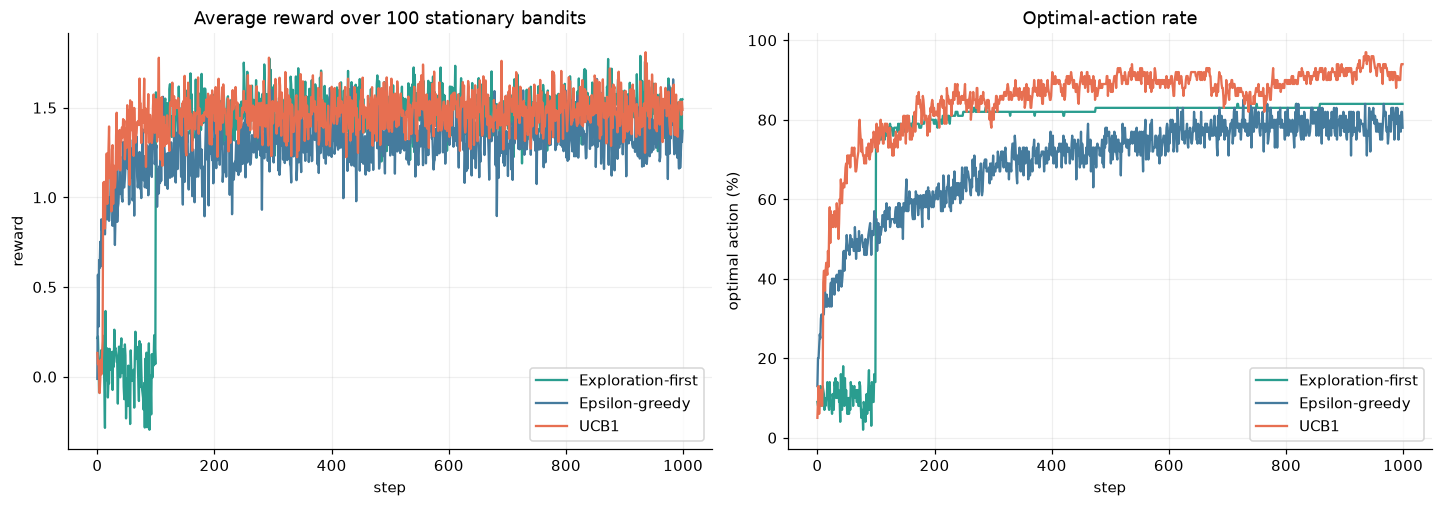

Final 200-step summary
 Exploration-first: reward=1.489, optimal action=83.7%
    Epsilon-greedy: reward=1.363, optimal action=78.9%
              UCB1: reward=1.495, optimal action=91.9%


In [4]:
def run_bandit_benchmark(agent_factories, runs=100, steps=1000, k=10):
    reward_history = {
        name: np.zeros((runs, steps), dtype=float)
        for name in agent_factories
    }
    optimal_history = {
        name: np.zeros((runs, steps), dtype=float)
        for name in agent_factories
    }

    for run in range(runs):
        environment_rng = np.random.default_rng(SEED + run)
        means = environment_rng.normal(size=k)
        bandit = GaussianBandit(means)
        for offset, (name, factory) in enumerate(agent_factories.items()):
            agent = factory(k, 10_000 * run + offset)
            reward_rng = np.random.default_rng(100_000 + 100 * run + offset)
            for step in range(steps):
                action = agent.select_action()
                reward = bandit.pull(action, reward_rng)
                agent.update(action, reward)
                reward_history[name][run, step] = reward
                optimal_history[name][run, step] = (
                    action == bandit.optimal_action
                )
    return reward_history, optimal_history


bandit_agents = {
    "Exploration-first": lambda k, seed: ExplorationFirstAgent(
        k, seed, exploration_steps=100
    ),
    "Epsilon-greedy": lambda k, seed: EpsilonGreedyAgent(
        k, seed, epsilon=0.1
    ),
    "UCB1": lambda k, seed: UCB1Agent(
        k, seed, exploration_coefficient=1.0
    ),
}
bandit_rewards, bandit_optimal = run_bandit_benchmark(bandit_agents)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
colors = ["#2a9d8f", "#457b9d", "#e76f51"]
for (name, values), color in zip(bandit_rewards.items(), colors):
    axes[0].plot(values.mean(axis=0), label=name, color=color)
    axes[1].plot(
        100 * bandit_optimal[name].mean(axis=0), label=name, color=color
    )
axes[0].set_title("Average reward over 100 stationary bandits")
axes[0].set_ylabel("reward")
axes[1].set_title("Optimal-action rate")
axes[1].set_ylabel("optimal action (%)")
for axis in axes:
    axis.set_xlabel("step")
    axis.grid(alpha=0.2)
    axis.legend()
plt.show()

print("Final 200-step summary")
for name in bandit_agents:
    reward = bandit_rewards[name][:, -200:].mean()
    optimal = 100 * bandit_optimal[name][:, -200:].mean()
    print(f"{name:>18}: reward={reward:.3f}, optimal action={optimal:.1f}%")

### 2.1 Reading the comparison

Exploration-first can commit to an incorrectly estimated arm because it never deliberately explores again. $\epsilon$-greedy keeps adapting, but a fixed fraction of its late actions remains random. UCB1 assigns its exploration budget to actions with high uncertainty and lets that bonus shrink with evidence.

The important transfer is structural: in a bandit, every arm has a count and an estimated return; in MCTS, every **child edge** has a visit count and an estimated outcome. UCT applies an upper-confidence score locally while descending the tree.

## 3. Kaggle ConnectX

Kaggle ConnectX uses a row-major flat board with `0 = empty`, `1 = player 1`, and `2 = player 2`. A legal action is a non-full column. A terminal reward is `+1` for the winner, `-1` for the loser, and `0` for a draw. These fields are defined by Kaggle's [official ConnectX specification](https://github.com/Kaggle/kaggle-environments/blob/master/kaggle_environments/envs/connectx/connectx.json).

The environment's built-in policies are `random` and `negamax`. The latter performs a depth-limited adversarial search and is a substantially harder reference than random play.

In [5]:
kaggle_game = make("connectx", configuration=CONNECTX_CONFIG, debug=True)
print("Configuration:", dict(kaggle_game.configuration))
print("Built-in agents:", sorted(kaggle_game.agents))

random_steps = kaggle_game.run(["random", "random"])
random_rewards = [float(agent.reward) for agent in kaggle_game.state]
print("Random-vs-random moves:", len(random_steps) - 1)
print("Final rewards:", random_rewards)
print(kaggle_game.render(mode="ansi"))

kaggle_game.render(mode="ipython")

Configuration: {'rows': 6, 'columns': 7, 'inarow': 4, 'actTimeout': 5, 'episodeSteps': 1000, 'runTimeout': 1200, 'agentTimeout': 60, 'timeout': 2}
Built-in agents: ['negamax', 'random']
Random-vs-random moves: 11
Final rewards: [1.0, -1.0]
+---+---+---+---+---+---+---+
| 0 | 0 | 0 | 0 | 0 | 0 | 0 |
+---+---+---+---+---+---+---+
| 0 | 0 | 0 | 0 | 0 | 0 | 0 |
+---+---+---+---+---+---+---+
| 0 | 0 | 0 | 0 | 0 | 0 | 0 |
+---+---+---+---+---+---+---+
| 0 | 0 | 2 | 0 | 0 | 0 | 0 |
+---+---+---+---+---+---+---+
| 2 | 0 | 2 | 2 | 1 | 0 | 0 |
+---+---+---+---+---+---+---+
| 1 | 1 | 1 | 1 | 1 | 0 | 2 |
+---+---+---+---+---+---+---+



## 4. A Search-Compatible State

Search should be independent of the display engine. `ConnectXState` therefore implements only the game model required by planning: legal actions, deterministic transitions, winner detection, terminal detection, and outcomes from a requested player's perspective. `from_kaggle()` is the adapter boundary between Kaggle observations and the search code.

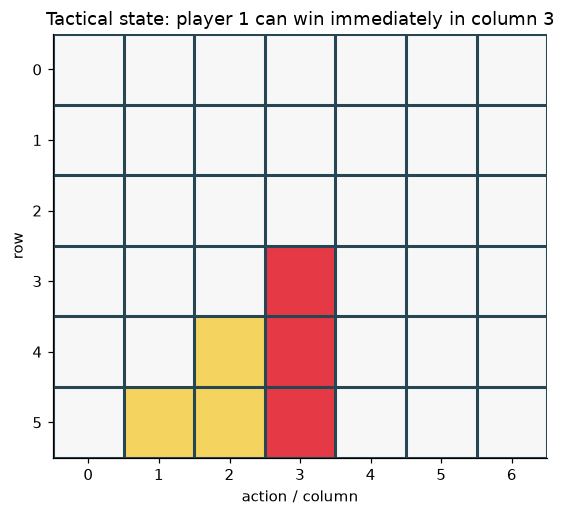

Player to move: 1
Legal actions: [0, 1, 2, 3, 4, 5, 6]
Winner before action: 0
Winner after column 3: 1


In [6]:
@dataclass
class ConnectXState:
    board: np.ndarray
    player: int = 1

    def __post_init__(self):
        board = np.asarray(self.board, dtype=np.int8)
        if board.size != ROWS * COLUMNS:
            raise ValueError("ConnectX board must contain 42 cells")
        self.board = board.reshape(ROWS, COLUMNS).copy()
        if self.player not in (1, 2):
            raise ValueError("player must be 1 or 2")

    @classmethod
    def empty(cls):
        return cls(np.zeros((ROWS, COLUMNS), dtype=np.int8), player=1)

    @classmethod
    def from_kaggle(cls, observation):
        return cls(np.asarray(observation.board), int(observation.mark))

    def legal_actions(self):
        return np.flatnonzero(self.board[0] == 0).astype(int).tolist()

    def next_state(self, action):
        action = int(action)
        if action not in self.legal_actions():
            raise ValueError(f"illegal ConnectX action: {action}")
        next_board = self.board.copy()
        empty_rows = np.flatnonzero(next_board[:, action] == 0)
        next_board[int(empty_rows[-1]), action] = self.player
        return ConnectXState(next_board, 3 - self.player)

    def winner(self):
        directions = ((0, 1), (1, 0), (1, 1), (1, -1))
        for row in range(ROWS):
            for column in range(COLUMNS):
                mark = int(self.board[row, column])
                if mark == 0:
                    continue
                for dr, dc in directions:
                    end_row = row + (INAROW - 1) * dr
                    end_column = column + (INAROW - 1) * dc
                    if not (0 <= end_row < ROWS and 0 <= end_column < COLUMNS):
                        continue
                    if all(
                        self.board[row + step * dr, column + step * dc]
                        == mark
                        for step in range(INAROW)
                    ):
                        return mark
        return 0

    def is_terminal(self):
        return self.winner() != 0 or not self.legal_actions()

    def outcome(self, perspective_player):
        winner = self.winner()
        if winner == 0:
            return 0.0
        return 1.0 if winner == perspective_player else -1.0

    def kaggle_board(self):
        return self.board.reshape(-1).astype(int).tolist()


def state_from_actions(actions):
    state = ConnectXState.empty()
    for action in actions:
        state = state.next_state(action)
    return state


def plot_connectx(state, axis=None, title=None, last_action=None):
    if axis is None:
        _, axis = plt.subplots(figsize=(6.5, 5))
    display_board = np.flipud(state.board)
    axis.imshow(
        display_board,
        cmap=ListedColormap(["#f7f7f7", "#e63946", "#f4d35e"]),
        vmin=0,
        vmax=2,
        origin="lower",
    )
    axis.set_xticks(range(COLUMNS))
    axis.set_yticks(range(ROWS))
    axis.set_yticklabels(range(ROWS - 1, -1, -1))
    axis.set_xlabel("action / column")
    axis.set_ylabel("row")
    axis.set_xticks(np.arange(-0.5, COLUMNS, 1), minor=True)
    axis.set_yticks(np.arange(-0.5, ROWS, 1), minor=True)
    axis.grid(which="minor", color="#264653", linewidth=2)
    axis.tick_params(which="minor", bottom=False, left=False)
    if title:
        axis.set_title(title)
    return axis


tactical_state = state_from_actions([3, 2, 3, 2, 3, 1])
plot_connectx(
    tactical_state,
    title="Tactical state: player 1 can win immediately in column 3",
)
plt.show()
print("Player to move:", tactical_state.player)
print("Legal actions:", tactical_state.legal_actions())
print("Winner before action:", tactical_state.winner())
print("Winner after column 3:", tactical_state.next_state(3).winner())

## 5. Monte Carlo Tree Search with UCT

One MCTS simulation has four phases:

1. **Selection:** descend through fully expanded nodes using UCT.
2. **Expansion:** add one untried legal action.
3. **Simulation:** play uniformly random actions to a terminal state.
4. **Backpropagation:** update every node on the path.

For parent $s$ and child $s'$, we use

$$\operatorname{UCT}(s,s')=-\bar V(s')+c\sqrt{\frac{\log N(s)}{N(s')}}.$$

Each node stores value from the perspective of the **player to move at that node**. The child is an opponent-to-move state, so selection negates its mean value. Backpropagation likewise flips the sign at every edge. This explicit convention prevents one of the most common two-player MCTS bugs.

In [7]:
class UCTNode:
    def __init__(self, state, parent=None, action=None):
        self.state = state
        self.parent = parent
        self.action = action
        self.children = {}
        self.untried_actions = list(state.legal_actions())
        self.visits = 0
        self.value_sum = 0.0

    @property
    def mean_value(self):
        return self.value_sum / self.visits if self.visits else 0.0

    def uct_score(self, child, exploration=math.sqrt(2)):
        if child.visits == 0:
            return float("inf")
        exploitation = -child.mean_value
        exploration_bonus = exploration * math.sqrt(
            math.log(max(1, self.visits)) / child.visits
        )
        return exploitation + exploration_bonus


def select_uct_child(node, exploration, rng):
    children = list(node.children.values())
    scores = np.array(
        [node.uct_score(child, exploration) for child in children]
    )
    candidates = np.flatnonzero(np.isclose(scores, scores.max()))
    return children[int(rng.choice(candidates))]


def random_rollout(state, rng):
    rollout_player = state.player
    rollout_state = state
    while not rollout_state.is_terminal():
        action = int(rng.choice(rollout_state.legal_actions()))
        rollout_state = rollout_state.next_state(action)
    return rollout_state.outcome(rollout_player)


def backpropagate_alternating(node, value):
    while node is not None:
        node.visits += 1
        node.value_sum += value
        value = -value
        node = node.parent


def run_uct_search(
    root_state,
    simulations=160,
    exploration=math.sqrt(2),
    seed=0,
):
    if root_state.is_terminal():
        raise ValueError("cannot search from a terminal state")
    rng = np.random.default_rng(seed)
    root = UCTNode(root_state)

    for _ in range(simulations):
        node = root

        while (
            not node.untried_actions
            and node.children
            and not node.state.is_terminal()
        ):
            node = select_uct_child(node, exploration, rng)

        if node.untried_actions and not node.state.is_terminal():
            index = int(rng.integers(len(node.untried_actions)))
            action = node.untried_actions.pop(index)
            child = UCTNode(
                node.state.next_state(action), parent=node, action=action
            )
            node.children[action] = child
            node = child

        value = random_rollout(node.state, rng)
        backpropagate_alternating(node, value)

    best_action = max(
        root.children,
        key=lambda action: (
            root.children[action].visits,
            -root.children[action].mean_value,
        ),
    )
    return int(best_action), root

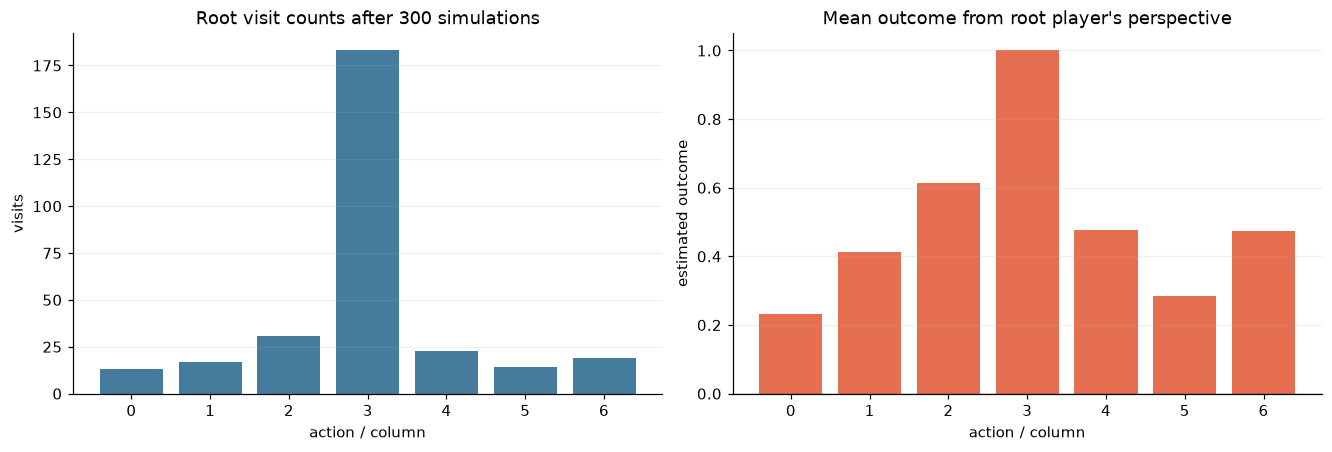

Selected tactical action: 3
Immediate win found: True
column 0: visits= 13, root value=+0.231
column 1: visits= 17, root value=+0.412
column 2: visits= 31, root value=+0.613
column 3: visits=183, root value=+1.000
column 4: visits= 23, root value=+0.478
column 5: visits= 14, root value=+0.286
column 6: visits= 19, root value=+0.474


In [8]:
tactical_action, tactical_root = run_uct_search(
    tactical_state, simulations=300, seed=SEED
)
actions = sorted(tactical_root.children)
visits = [tactical_root.children[action].visits for action in actions]
root_values = [
    -tactical_root.children[action].mean_value for action in actions
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].bar(actions, visits, color="#457b9d")
axes[0].set_title("Root visit counts after 300 simulations")
axes[0].set_ylabel("visits")
axes[1].bar(actions, root_values, color="#e76f51")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Mean outcome from root player's perspective")
axes[1].set_ylabel("estimated outcome")
for axis in axes:
    axis.set_xlabel("action / column")
    axis.set_xticks(range(COLUMNS))
    axis.grid(axis="y", alpha=0.2)
plt.show()

print("Selected tactical action:", tactical_action)
print("Immediate win found:", tactical_state.next_state(tactical_action).winner() == 1)
for action in actions:
    child = tactical_root.children[action]
    print(
        f"column {action}: visits={child.visits:3d}, "
        f"root value={-child.mean_value:+.3f}"
    )

### 5.1 Kaggle adapter and built-in-agent evaluation

Kaggle calls an agent with `(observation, configuration)` and expects an integer column. The adapter reconstructs our internal state and derives a deterministic seed from the board, making repeated evaluations reproducible.

Every benchmark alternates which side the tested agent plays. This matters because first-player advantage can otherwise be mistaken for agent strength. We report win, draw, and loss counts rather than only a mean reward.

In [9]:
def board_seed(board, mark, offset=0):
    weighted = sum((index + 1) * int(value) for index, value in enumerate(board))
    return int((weighted + 997 * int(mark) + offset) % (2**32 - 1))


def rollout_mcts_agent(observation, configuration):
    state = ConnectXState.from_kaggle(observation)
    action, _ = run_uct_search(
        state,
        simulations=50,
        exploration=math.sqrt(2),
        seed=board_seed(observation.board, observation.mark),
    )
    return action


def benchmark_kaggle_agent(
    tested_agent,
    opponent,
    games_each_side=6,
    configuration=CONNECTX_CONFIG,
    seed=2026,
):
    results = Counter(win=0, draw=0, loss=0)

    # Kaggle's built-in random and negamax agents use Python's global RNG.
    # Reset both RNGs before each side so results do not depend on cell order.
    random.seed(seed)
    np.random.seed(seed)
    first_rewards = evaluate(
        "connectx",
        [tested_agent, opponent],
        configuration=configuration,
        num_episodes=games_each_side,
    )
    random.seed(seed + 1)
    np.random.seed(seed + 1)
    second_rewards = evaluate(
        "connectx",
        [opponent, tested_agent],
        configuration=configuration,
        num_episodes=games_each_side,
    )
    tested_rewards = [pair[0] for pair in first_rewards] + [
        pair[1] for pair in second_rewards
    ]
    for reward in tested_rewards:
        if reward is None:
            results["loss"] += 1
        elif reward > 0:
            results["win"] += 1
        elif reward < 0:
            results["loss"] += 1
        else:
            results["draw"] += 1
    return dict(results)


uct_vs_random = benchmark_kaggle_agent(
    rollout_mcts_agent, "random", games_each_side=6
)
print("UCT MCTS vs Kaggle random (12 games):", uct_vs_random)

kaggle_game = make("connectx", configuration=CONNECTX_CONFIG, debug=True)
kaggle_game.run([rollout_mcts_agent, "random"])
print("Demo rewards:", [agent.reward for agent in kaggle_game.state])
kaggle_game.render(mode="ipython")

UCT MCTS vs Kaggle random (12 games): {'win': 11, 'draw': 0, 'loss': 1}
Demo rewards: [1, -1]


## 6. From UCT to an AlphaZero-Style Agent

Random rollouts become expensive and noisy as games grow. An AlphaZero-style search replaces them with one network that predicts:

- policy logits $\mathbf{p}_\theta(s)$, a prior over the seven columns;
- value $v_\theta(s)\in[-1,1]$, the expected outcome for the **player to move**.

The board encoding uses three $6\times7$ planes: current-player pieces, opponent pieces, and side to move. Current-player-relative planes let one network handle both marks with one value convention.

The model is small enough for a classroom run but still uses convolution, a residual block, policy and value heads, and batched replay optimization. The first probe below is placed on `DEVICE` so its output verifies the ROCm tensor path.

### 6.1 State encoding and policy–value network

In [10]:
def encode_state(state):
    current = (state.board == state.player).astype(np.float32)
    opponent = (state.board == (3 - state.player)).astype(np.float32)
    side_to_move = np.full(
        (ROWS, COLUMNS),
        1.0 if state.player == 1 else 0.0,
        dtype=np.float32,
    )
    return np.stack([current, opponent, side_to_move], axis=0)


class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(
            channels, channels, kernel_size=3, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(
            channels, channels, kernel_size=3, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, inputs):
        hidden = F.relu(self.bn1(self.conv1(inputs)))
        hidden = self.bn2(self.conv2(hidden))
        return F.relu(inputs + hidden)


class PolicyValueNetwork(nn.Module):
    def __init__(self, channels=32):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
        )
        self.residual = ResidualBlock(channels)
        self.policy_head = nn.Sequential(
            nn.Conv2d(channels, 2, kernel_size=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(2 * ROWS * COLUMNS, COLUMNS),
        )
        self.value_features = nn.Sequential(
            nn.Conv2d(channels, 1, kernel_size=1),
            nn.ReLU(),
            nn.Flatten(),
        )
        self.value_head = nn.Sequential(
            nn.Linear(ROWS * COLUMNS, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Tanh(),
        )

    def forward(self, inputs):
        features = self.residual(self.stem(inputs))
        policy_logits = self.policy_head(features)
        value = self.value_head(self.value_features(features)).squeeze(-1)
        return policy_logits, value


policy_value_net = PolicyValueNetwork().to(DEVICE)
encoded = torch.from_numpy(encode_state(tactical_state)).unsqueeze(0)
policy_value_net.eval()
with torch.no_grad():
    test_logits, test_value = policy_value_net(encoded.to(DEVICE))

print("Encoded state shape:", tuple(encoded.shape))
print("Policy logits shape:", tuple(test_logits.shape))
print("Value shape:", tuple(test_value.shape))
print(
    "Trainable parameters:",
    sum(parameter.numel() for parameter in policy_value_net.parameters()),
)

Encoded state shape: (1, 3, 6, 7)
Policy logits shape: (1, 7)
Value shape: (1,)
Trainable parameters: 22999


MIOpen(HIP): Warning [ParseAndLoadDb] File is unreadable: "/usr/local/lib/python3.12/dist-packages/_rocm_sdk_libraries_gfx1151/share/miopen/db/gfx1151_20.HIP.fdb.txt"


### 6.2 Legal-action masking and PUCT

The policy head always emits seven logits, including columns that may be full. Illegal logits are masked before softmax. If a node is terminal, the network is skipped and the exact outcome is returned.

`PUCTNode.mean_value` uses the player-to-move perspective. Consequently, both selection and backpropagation use the same alternating-sign convention as UCT. Keeping one convention throughout the implementation is more important than choosing a particular convention.

In [11]:
def network_policy_value(state, net, device=DEVICE):
    if state.is_terminal():
        return np.zeros(COLUMNS, dtype=np.float32), state.outcome(state.player)

    inputs = torch.from_numpy(encode_state(state)).unsqueeze(0).to(device)
    legal = state.legal_actions()
    net.eval()
    with torch.no_grad():
        logits, value = net(inputs)
        masked_logits = torch.full_like(logits[0], -torch.inf)
        masked_logits[legal] = logits[0, legal]
        priors = torch.softmax(masked_logits, dim=0).cpu().numpy()
    return priors.astype(np.float32), float(value.item())


class PUCTNode:
    def __init__(self, state, parent=None, action=None, prior=1.0):
        self.state = state
        self.parent = parent
        self.action = action
        self.prior = float(prior)
        self.children = {}
        self.visits = 0
        self.value_sum = 0.0

    @property
    def mean_value(self):
        return self.value_sum / self.visits if self.visits else 0.0

    def expand(self, priors):
        for action in self.state.legal_actions():
            if action not in self.children:
                self.children[action] = PUCTNode(
                    self.state.next_state(action),
                    parent=self,
                    action=action,
                    prior=float(priors[action]),
                )


def select_puct_child(node, c_puct, rng):
    children = list(node.children.values())
    sqrt_parent_visits = math.sqrt(max(1, node.visits))
    scores = np.array(
        [
            -child.mean_value
            + c_puct
            * child.prior
            * sqrt_parent_visits
            / (1 + child.visits)
            for child in children
        ]
    )
    candidates = np.flatnonzero(np.isclose(scores, scores.max()))
    return children[int(rng.choice(candidates))]


def add_dirichlet_noise(node, rng, alpha=0.3, fraction=0.25):
    if not node.children:
        return
    actions = list(node.children)
    noise = rng.dirichlet(np.full(len(actions), alpha))
    for action, noise_value in zip(actions, noise):
        child = node.children[action]
        child.prior = (
            (1 - fraction) * child.prior + fraction * float(noise_value)
        )


def run_puct_search(
    root_state,
    net,
    simulations=40,
    c_puct=1.5,
    device=DEVICE,
    seed=0,
    root_noise=False,
):
    if root_state.is_terminal():
        raise ValueError("cannot search from a terminal state")
    rng = np.random.default_rng(seed)
    root = PUCTNode(root_state)

    for simulation in range(simulations):
        node = root
        while node.children and not node.state.is_terminal():
            node = select_puct_child(node, c_puct, rng)

        priors, value = network_policy_value(node.state, net, device)
        if not node.state.is_terminal():
            node.expand(priors)
            if node is root and root_noise:
                add_dirichlet_noise(node, rng)
        backpropagate_alternating(node, value)
    return root


def root_visit_policy(root, temperature=1.0):
    counts = np.zeros(COLUMNS, dtype=np.float64)
    priors = np.zeros(COLUMNS, dtype=np.float64)
    for action, child in root.children.items():
        counts[action] = child.visits
        priors[action] = child.prior

    if temperature <= 1e-8:
        policy = np.zeros(COLUMNS, dtype=np.float64)
        best = np.flatnonzero(counts == counts.max())
        policy[int(best[0])] = 1.0
        return policy.astype(np.float32)

    if counts.sum() == 0:
        policy = priors / priors.sum()
    else:
        scaled = counts ** (1.0 / temperature)
        policy = scaled / scaled.sum()
    return policy.astype(np.float32)


untrained_root = run_puct_search(
    tactical_state,
    policy_value_net,
    simulations=60,
    seed=SEED,
)
untrained_policy = root_visit_policy(untrained_root)
print("Untrained-network visit policy:", np.round(untrained_policy, 3))
print("Policy sum:", untrained_policy.sum())
print("Selected column:", int(np.argmax(untrained_policy)))

# Two tactical assertions verify the alternating-player value convention.
blocking_state = state_from_actions([0, 3, 1, 3, 6, 3])
blocking_root = run_puct_search(
    blocking_state,
    policy_value_net,
    simulations=400,
    seed=SEED + 68,
)
blocking_action = int(np.argmax(root_visit_policy(blocking_root, temperature=0.0)))

backup_parent = PUCTNode(ConnectXState.empty())
backup_child = PUCTNode(
    ConnectXState.empty().next_state(0),
    parent=backup_parent,
    action=0,
)
backpropagate_alternating(backup_child, -1.0)

assert int(np.argmax(untrained_policy)) == 3, "PUCT missed an immediate win"
assert blocking_action == 3, "PUCT missed a mandatory block"
assert backup_child.mean_value == -1.0 and backup_parent.mean_value == 1.0
print("Immediate-win test: passed (column 3)")
print("Mandatory-block test: passed (column 3)")
print("Perspective backup test: passed (leaf -1 -> parent +1)")


Untrained-network visit policy: [0.017 0.017 0.017 0.898 0.017 0.017 0.017]
Policy sum: 1.0
Selected column: 3
Immediate-win test: passed (column 3)
Mandatory-block test: passed (column 3)
Perspective backup test: passed (leaf -1 -> parent +1)


## 7. Self-Play and Replay Buffer

At every self-play position we store:

1. the current-player-relative board encoding $s$;
2. the normalized root visit counts $\pi$;
3. the final game outcome $z$ from that position's player's perspective.

Horizontal reflection supplies an exact Connect Four symmetry: the board planes and policy vector are both reversed, while the value target stays unchanged.

### CPU actor, GPU learner

MCTS evaluates one leaf at a time and immediately converts its small output to Python/NumPy for tree control. On this hardware, that synchronization makes single-position GPU inference slower than CPU inference. During an iteration we therefore use a frozen CPU copy as the self-play actor, collect a replay buffer, train batch-128 tensors on the Radeon GPU, and synchronize the actor once at the end. The policy is fixed during each data-collection phase, so this split does not change the algorithm.

In [12]:
class ReplayBuffer:
    def __init__(self, capacity=20000):
        self.data = deque(maxlen=capacity)

    def add(self, state_array, policy, value):
        self.data.append(
            (
                np.asarray(state_array, dtype=np.float32),
                np.asarray(policy, dtype=np.float32),
                float(value),
            )
        )

    def sample(self, batch_size, rng):
        indices = rng.choice(len(self.data), size=batch_size, replace=False)
        states, policies, values = zip(
            *(self.data[int(index)] for index in indices)
        )
        return (
            torch.from_numpy(np.stack(states)),
            torch.from_numpy(np.stack(policies)),
            torch.tensor(values, dtype=torch.float32),
        )

    def __len__(self):
        return len(self.data)


def self_play_game(
    net,
    simulations=32,
    c_puct=1.5,
    temperature_moves=10,
    device=DEVICE,
    seed=0,
):
    rng = np.random.default_rng(seed)
    state = ConnectXState.empty()
    history = []
    move = 0

    while not state.is_terminal():
        root = run_puct_search(
            state,
            net,
            simulations=simulations,
            c_puct=c_puct,
            device=device,
            seed=int(rng.integers(2**32 - 1)),
            root_noise=True,
        )
        temperature = 1.0 if move < temperature_moves else 0.15
        policy = root_visit_policy(root, temperature=temperature)
        history.append((encode_state(state), policy, state.player))
        action = int(rng.choice(COLUMNS, p=policy))
        state = state.next_state(action)
        move += 1

    winner = state.winner()
    examples = []
    for state_array, policy, player in history:
        value = 0.0 if winner == 0 else (1.0 if winner == player else -1.0)
        examples.append((state_array, policy, value))
        examples.append(
            (
                state_array[:, :, ::-1].copy(),
                policy[::-1].copy(),
                value,
            )
        )
    return examples, winner, move


def collect_self_play_games(
    net,
    replay_buffer,
    games,
    simulations,
    iteration,
    device=DEVICE,
):
    winners = []
    lengths = []
    for game in range(games):
        examples, winner, length = self_play_game(
            net,
            simulations=simulations,
            device=device,
            seed=SEED + 10_000 * iteration + game,
        )
        for example in examples:
            replay_buffer.add(*example)
        winners.append(winner)
        lengths.append(length)
    return np.asarray(winners), np.asarray(lengths)


def train_policy_value_step(
    net,
    optimizer,
    replay_buffer,
    batch_size,
    rng,
    device=DEVICE,
):
    states, target_policies, target_values = replay_buffer.sample(
        batch_size, rng
    )
    states = states.to(device)
    target_policies = target_policies.to(device)
    target_values = target_values.to(device)

    net.train()
    logits, predicted_values = net(states)
    policy_loss = -(
        target_policies * F.log_softmax(logits, dim=1)
    ).sum(dim=1).mean()
    value_loss = F.mse_loss(predicted_values, target_values)
    loss = policy_loss + value_loss

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=5.0)
    optimizer.step()

    policy_accuracy = (
        logits.argmax(dim=1) == target_policies.argmax(dim=1)
    ).float().mean()
    return {
        "loss": float(loss.detach()),
        "policy_loss": float(policy_loss.detach()),
        "value_loss": float(value_loss.detach()),
        "policy_accuracy": float(policy_accuracy.detach()),
    }

### 7.1 Reference-scale training loop

Full AlphaZero systems use much larger networks, batched inference, many parallel actors, checkpoint gating, and tree reuse. This notebook runs 20 iterations with 200 self-play games each: **4,000 games**, 50 PUCT simulations per move, and **1,000 GPU optimizer steps**, matching the reference notebook's self-play and search scale. Horizontal reflection doubles the stored examples.

We time self-play and learning separately. The expected result is not that every part becomes GPU work: branch-heavy search stays efficient on the CPU, while dense replay batches use ROCm. This measured division is the same principle used by larger actor–learner systems.

In [ ]:
torch.manual_seed(SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
    torch.cuda.reset_peak_memory_stats(DEVICE)

policy_value_net = PolicyValueNetwork(channels=32).to(DEVICE)
self_play_net = copy.deepcopy(policy_value_net).to(SEARCH_DEVICE).eval()
optimizer = torch.optim.Adam(
    policy_value_net.parameters(), lr=1e-3, weight_decay=1e-4
)
replay_buffer = ReplayBuffer(capacity=20000)
training_rng = np.random.default_rng(SEED)

TRAINING_ITERATIONS = 20
SELF_PLAY_GAMES = 200
SELF_PLAY_SIMULATIONS = 50
TRAIN_STEPS = 50
BATCH_SIZE = 128
training_history = []

if DEVICE.type == "cuda":
    torch.cuda.synchronize(DEVICE)
training_started = time.perf_counter()

for iteration in range(1, TRAINING_ITERATIONS + 1):
    self_play_started = time.perf_counter()
    winners, game_lengths = collect_self_play_games(
        self_play_net,
        replay_buffer,
        games=SELF_PLAY_GAMES,
        simulations=SELF_PLAY_SIMULATIONS,
        iteration=iteration,
        device=SEARCH_DEVICE,
    )
    self_play_seconds = time.perf_counter() - self_play_started

    step_statistics = []
    if DEVICE.type == "cuda":
        torch.cuda.synchronize(DEVICE)
    learner_started = time.perf_counter()
    if len(replay_buffer) >= BATCH_SIZE:
        for _ in range(TRAIN_STEPS):
            step_statistics.append(
                train_policy_value_step(
                    policy_value_net,
                    optimizer,
                    replay_buffer,
                    BATCH_SIZE,
                    training_rng,
                    device=DEVICE,
                )
            )
    if DEVICE.type == "cuda":
        torch.cuda.synchronize(DEVICE)
    learner_seconds = time.perf_counter() - learner_started

    # The actor remains frozen throughout collection and is refreshed only here.
    self_play_net.load_state_dict(policy_value_net.state_dict())
    self_play_net.eval()

    summary = {
        "iteration": iteration,
        "buffer_size": len(replay_buffer),
        "mean_game_length": float(game_lengths.mean()),
        "player1_win_rate": float(np.mean(winners == 1)),
        "draw_rate": float(np.mean(winners == 0)),
        "self_play_seconds": self_play_seconds,
        "learner_seconds": learner_seconds,
    }
    for key in ("loss", "policy_loss", "value_loss", "policy_accuracy"):
        summary[key] = float(
            np.mean([statistics[key] for statistics in step_statistics])
        )
    training_history.append(summary)
    print(
        f"Iteration {iteration:>2}/{TRAINING_ITERATIONS} | "
        f"buffer={summary['buffer_size']:5d} | "
        f"length={summary['mean_game_length']:4.1f} | "
        f"loss={summary['loss']:.3f} | "
        f"policy acc={100 * summary['policy_accuracy']:4.1f}% | "
        f"P1 wins={100 * summary['player1_win_rate']:2.0f}% | "
        f"draws={100 * summary['draw_rate']:2.0f}% | "
        f"CPU self-play={self_play_seconds:5.1f}s | "
        f"GPU learn={learner_seconds:4.2f}s"
    )

if DEVICE.type == "cuda":
    torch.cuda.synchronize(DEVICE)
training_seconds = time.perf_counter() - training_started
peak_memory_mib = (
    torch.cuda.max_memory_allocated(DEVICE) / 2**20
    if DEVICE.type == "cuda" else 0.0
)
print(f"Total training wall time: {training_seconds / 60:.1f} min")
print("Learner model device:", next(policy_value_net.parameters()).device)
print("Self-play actor device:", next(self_play_net.parameters()).device)
if DEVICE.type == "cuda":
    print(f"Peak PyTorch GPU memory: {peak_memory_mib:.1f} MiB")

Iteration  1/20 | buffer= 8448 | length=21.1 | loss=2.880 | policy acc=16.5% | P1 wins=58% | draws= 2% | CPU self-play= 59.2s | GPU learn=0.37s
Iteration  2/20 | buffer=16562 | length=20.3 | loss=2.792 | policy acc=18.3% | P1 wins=60% | draws= 4% | CPU self-play= 57.1s | GPU learn=0.12s


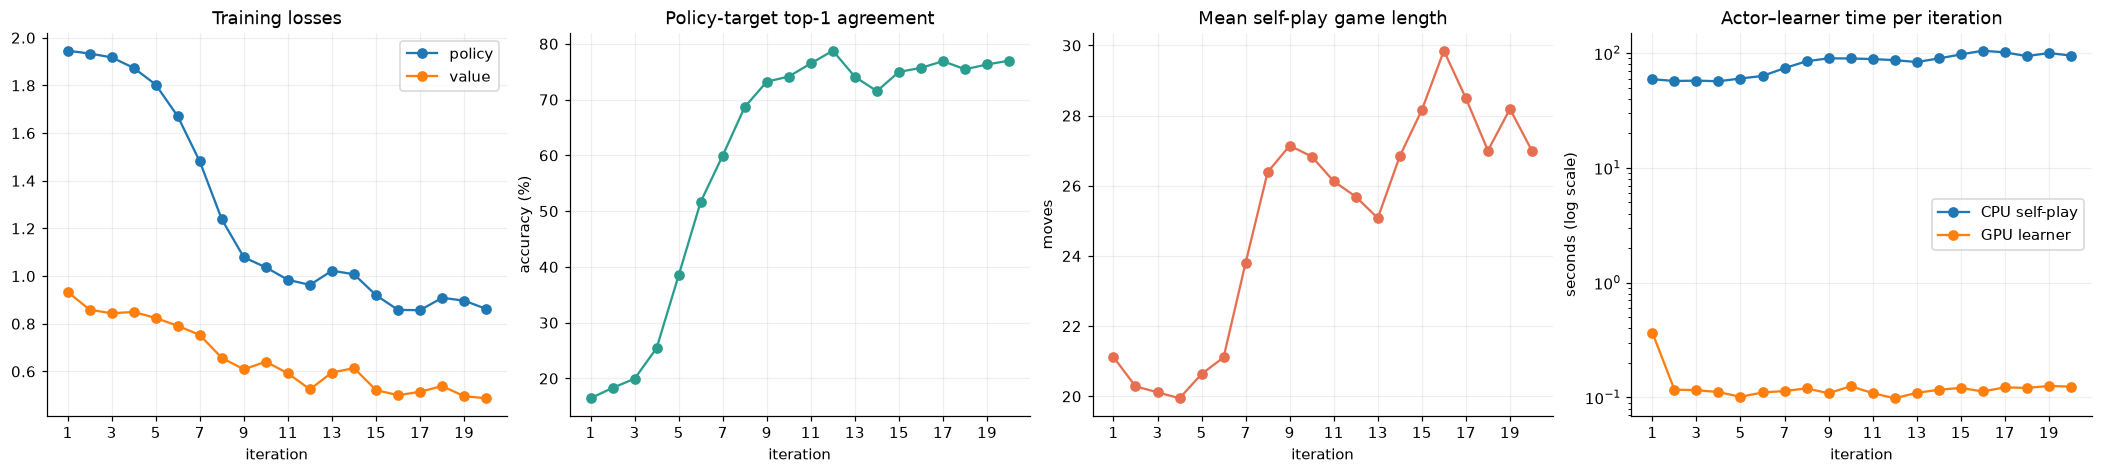

Saved checkpoint: /home/jovyan/work/artifacts/DRL03/connectx_policy_value.pt


In [18]:
iterations = [item["iteration"] for item in training_history]
fig, axes = plt.subplots(1, 4, figsize=(19, 4.2), constrained_layout=True)
axes[0].plot(
    iterations,
    [item["policy_loss"] for item in training_history],
    marker="o",
    label="policy",
)
axes[0].plot(
    iterations,
    [item["value_loss"] for item in training_history],
    marker="o",
    label="value",
)
axes[0].set_title("Training losses")
axes[0].legend()
axes[1].plot(
    iterations,
    [100 * item["policy_accuracy"] for item in training_history],
    marker="o",
    color="#2a9d8f",
)
axes[1].set_title("Policy-target top-1 agreement")
axes[1].set_ylabel("accuracy (%)")
axes[2].plot(
    iterations,
    [item["mean_game_length"] for item in training_history],
    marker="o",
    color="#e76f51",
)
axes[2].set_title("Mean self-play game length")
axes[2].set_ylabel("moves")
axes[3].plot(
    iterations,
    [item["self_play_seconds"] for item in training_history],
    marker="o",
    label="CPU self-play",
)
axes[3].plot(
    iterations,
    [item["learner_seconds"] for item in training_history],
    marker="o",
    label="GPU learner",
)
axes[3].set_yscale("log")
axes[3].set_title("Actor–learner time per iteration")
axes[3].set_ylabel("seconds (log scale)")
axes[3].legend()
for axis in axes:
    axis.set_xlabel("iteration")
    axis.set_xticks(iterations[::2])
    axis.grid(alpha=0.2)
plt.show()

checkpoint_path = ARTIFACT_DIR / "connectx_policy_value.pt"
torch.save(policy_value_net.state_dict(), checkpoint_path)
print("Saved checkpoint:", checkpoint_path.resolve())

## 8. AlphaZero-Style Agent vs Kaggle Negamax

Training losses describe optimization, not playing strength. We therefore evaluate only the final search-enhanced agent: the trained policy–value network with **200 PUCT simulations per move**, against Kaggle's depth-limited `negamax` policy.

The benchmark contains 20 games and alternates sides—10 games as player 1 and 10 as player 2. Wins, draws, and losses are always reported from the AlphaZero-style agent's perspective. The replay below is a separate deterministic demonstration with the AlphaZero-style agent moving first; it is not included in the benchmark counts.


In [19]:
ALPHAZERO_SIMULATIONS = 200
EVALUATION_GAMES_EACH_SIDE = 10


def alphazero_agent(observation, configuration):
    state = ConnectXState.from_kaggle(observation)
    root = run_puct_search(
        state,
        policy_value_net,
        simulations=ALPHAZERO_SIMULATIONS,
        c_puct=1.5,
        device=DEVICE,
        seed=board_seed(observation.board, observation.mark, offset=17),
    )
    return int(np.argmax(root_visit_policy(root, temperature=0.0)))


alphazero_vs_negamax = benchmark_kaggle_agent(
    alphazero_agent,
    "negamax",
    games_each_side=EVALUATION_GAMES_EACH_SIDE,
)
total_evaluation_games = 2 * EVALUATION_GAMES_EACH_SIDE

print(
    f"AlphaZero-style PUCT-{ALPHAZERO_SIMULATIONS} vs Kaggle negamax"
)
print(
    f"Games: {total_evaluation_games} "
    f"({EVALUATION_GAMES_EACH_SIDE} as player 1, "
    f"{EVALUATION_GAMES_EACH_SIDE} as player 2)"
)
print(f"{'win':>5} {'draw':>5} {'loss':>5}")
print("-" * 17)
print(
    f"{alphazero_vs_negamax['win']:>5} "
    f"{alphazero_vs_negamax['draw']:>5} "
    f"{alphazero_vs_negamax['loss']:>5}"
)

kaggle_game = make("connectx", configuration=CONNECTX_CONFIG, debug=True)
kaggle_game.run([alphazero_agent, "negamax"])
print(
    "Visualization rewards (AlphaZero-style, negamax):",
    [agent.reward for agent in kaggle_game.state],
)
kaggle_game.render(mode="ipython")

AlphaZero-style PUCT-200 vs Kaggle negamax
Games: 20 (10 as player 1, 10 as player 2)
  win  draw  loss
-----------------
   17     3     0
Visualization rewards (AlphaZero-style, negamax): [1, -1]


## Conclusions

In this lab, you completed the progression from optimism under uncertainty to search-guided learning:

- Compared exploration-first, ε-greedy, and UCB1 under controlled bandit trials
- Implemented a Kaggle-compatible Connect Four state and native visualization
- Built UCT with selection, expansion, rollout, and alternating-sign backup
- Verified immediate-win, mandatory-block, and value-perspective invariants
- Constructed a residual policy–value network and legally masked PUCT
- Generated 4,000 self-play games with root visit targets and reflection augmentation
- Trained 1,000 replay batches on the AMD Radeon GPU through ROCm
- Measured the CPU actor and GPU learner separately and synchronized them once per iteration
- Benchmarked rollout UCT against Kaggle's random policy
- Evaluated the final PUCT-200 agent against depth-limited negamax from both sides
- Saved the trained checkpoint and rendered interactive ConnectX replays

The central lesson is architectural: **search improves a policy locally, and learning amortizes those improvements into a reusable network**. Efficient systems also place each workload deliberately—branch-heavy environments and trees on CPUs, dense batched learning on GPUs.

---

### References

- [Kaggle Environments: official repository and API examples](https://github.com/Kaggle/kaggle-environments)
- [Kaggle ConnectX implementation and built-in agents](https://github.com/Kaggle/kaggle-environments/blob/master/kaggle_environments/envs/connectx/connectx.py)
- [Auer et al. (2002), Finite-time Analysis of the Multiarmed Bandit Problem](https://link.springer.com/article/10.1023/A:1013689704352)
- [Silver et al. (2017), Mastering the Game of Go without Human Knowledge](https://www.nature.com/articles/nature24270)
- [Silver et al. (2017), Mastering Chess and Shogi by Self-Play](https://arxiv.org/abs/1712.01815)